 - 네이버 영화평 감성분석: LSTM

In [ ]:
!pip install Konlpy

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 19.4 MB 5.1 MB/s 
     |████████████████████████████████| 453 kB 58.6 MB/s 


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 네이버 영화 리뷰 데이터로 검색
train_df = pd.read_csv('https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt', sep='\t')
test_df = pd.read_csv('https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt', sep='\t')

In [ ]:
print(train_df.shape, test_df.shape)
train_df.head(3)

(150000, 3) (50000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0


### 데이터 전처리

 - 훈련 데이터셋 전처리

In [ ]:
# Null 데이터가 있는지 확인
train_df.isna().sum()

id          0
document    5
label       0
dtype: int64

In [ ]:
# Null 데이터 제거
train_df.dropna(how='any', inplace=True)
train_df.shape

(149995, 3)

In [ ]:
# 중복여부 확인
train_df.document.nunique()

146182

In [ ]:
# 중복 데이터 제거
train_df.drop_duplicates(subset=['document'], inplace=True)
train_df.shape

(146182, 3)

In [ ]:
# 긍정(1)/부정(0) 분포
train_df.label.value_counts()

0    73342
1    72840
Name: label, dtype: int64

 - 테스트 데이터셋 전처리

In [ ]:
test_df.isna().sum()

id          0
document    3
label       0
dtype: int64

In [ ]:
# NaN 데이터 제거
test_df.dropna(how='any', inplace=True)
test_df.shape

(49997, 3)

In [ ]:
test_df.document.nunique()

49157

In [ ]:
# 중복 데이터 제거
test_df.drop_duplicates(subset=['document'], inplace=True)
test_df.shape

(49157, 3)

In [ ]:
# 긍정(1)  / 부정(0) 분포
test_df.label.value_counts()

1    24711
0    24446
Name: label, dtype: int64

### 한글 텍스트 전처리
 - train dataset

In [ ]:
# 한글 이외의 문자는 공백으로 처리하고 strip
train_df.document = train_df.document.str.replace('[^ㄱ-ㅎㅏ-ㅣ가-힣]',' ').str.strip()
train_df.head(3)

,id,document,label
0,9976970,아 더빙 진짜 짜증나네요 목소리,0
1,3819312,흠 포스터보고 초딩영화줄 오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0


In [ ]:
# '' 만 남은 데이터 --> np.nan 으로 대체한 후 제거
train_df.document.replace('', np.nan, inplace=True)
train_df.document.isna().sum()

789

In [ ]:
train_df.dropna(how='any', inplace=True)
train_df.shape

(145393, 3)

 - test data set

In [ ]:
# 한글 이외 문자 공백 처리하고 strip()
test_df.document = test_df.document.str.replace('[^ㄱ-ㅎㅏ-ㅣ가-힣]',' ').str.strip()
test_df.head()

,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,,0
2,8544678,뭐야 이 평점들은 나쁘진 않지만 점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임 돈주고 보기에는,0
4,6723715,만 아니었어도 별 다섯 개 줬을텐데 왜 로 나와서 제 심기를 불편하게 하죠,0


In [ ]:
# ' ' 만 남은 데이터 --> np.nan 대체 후 제거
test_df.document = test_df.document.str.replace('[^ㄱ-ㅎㅏ-ㅣ가-힣]',' ').str.strip()
test_df.document.replace('', np.nan, inplace=True)
test_df.dropna(how='any', inplace=True)
test_df.shape

(48852, 3)

### 한글 형태소 분석

In [ ]:
from konlpy.tag import Okt
okt = Okt()

 - 불용어 사전 세팅

In [ ]:
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다','을','ㅋㅋ','ㅠㅠ','ㅎㅎ', '에게', '에', '구만', '구먼']

In [ ]:
from tqdm.notebook import tqdm

X_train = []
for sentence in tqdm(train_df.document):
    morphs = okt.morphs(sentence, stem=True)
    tmp_X = [word for word in morphs if word not in stopwords]
    X_train.append(tmp_X)

  0%|          | 0/145393 [00:00<?, ?it/s]

In [ ]:
X_train[:3]

[['아', '더빙', '진짜', '짜증나다', '목소리'],
 ['흠', '포스터', '보고', '초딩', '영화', '줄', '오버', '연기', '조차', '가볍다', '않다'],
 ['너', '무재', '밓었', '다그', '래서', '보다', '추천', '다']]

### Keras Tokenizer => Train / Test dataset
 - 시간 관계 상 train dataset을 train/test 데이터셋으로 쪼개서 사용

In [ ]:
import tensorflow as tf
seed = 2022
np.random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
t=Tokenizer()
t.fit_on_texts(X_train)

NameError: ignored

In [ ]:
len(t.word_index)

43115

In [ ]:
# 빈도수 상위 20000개 단어로 인코딩
num_words = 20000
t = Tokenizer(num_words=num_words)
t.fit_on_texts(X_train)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_train, train_df.label.values, stratify=train_df.label.values,
                                                    test_size=0.2, random_state=seed)

In [ ]:
# 데이터 분포 파악용
X_train = t.texts_to_sequences(X_train)
X_test = t.texts_to_sequences(X_test)

In [ ]:
# 데이터의 최대 길이, 평균 길이
max(len(s) for s in X_train), sum(map(len, X_train)) / len(X_train)

(70, 10.583085441133484)

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_len = 40
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)
X_train.shape, X_test.shape

((116314, 40), (29079, 40))

### LSTM 모델 정의 / 설정 / 학습

In [ ]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
model = Sequential([
                    Embedding(num_words, 120, input_length=max_len),
                    LSTM(128),
                    Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 40, 120)           2400000   
                                                                 
 lstm (LSTM)                 (None, 128)               127488    
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                                 
Total params: 2,527,617
Trainable params: 2,527,617
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model.compile('adam', 'binary_crossentropy', ['accuracy'])
model_path = 'best_naver_movie_lstm.h5'
mc = ModelCheckpoint(model_path, verbose=1, save_best_only=True)
es = EarlyStopping(patience=5)

In [ ]:
hist = model.fit(X_train, y_train, validation_split=0.2, epochs=30, batch_size=128, callbacks=[mc,es])

Epoch 1/30
725/727 [============================>.] - ETA: 0s - loss: 0.4031 - accuracy: 0.8147
Epoch 1: val_loss improved from inf to 0.36527, saving model to best_naver_movie_lstm.h5
727/727 [==============================] - 15s 9ms/step - loss: 0.4030 - accuracy: 0.8148 - val_loss: 0.3653 - val_accuracy: 0.8392
Epoch 2/30
727/727 [==============================] - ETA: 0s - loss: 0.3113 - accuracy: 0.8678
Epoch 2: val_loss improved from 0.36527 to 0.36067, saving model to best_naver_movie_lstm.h5
727/727 [==============================] - 9s 13ms/step - loss: 0.3113 - accuracy: 0.8678 - val_loss: 0.3607 - val_accuracy: 0.8428
Epoch 3/30
723/727 [============================>.] - ETA: 0s - loss: 0.2582 - accuracy: 0.8927
Epoch 3: val_loss did not improve from 0.36067
727/727 [==============================] - 10s 13ms/step - loss: 0.2584 - accuracy: 0.8925 - val_loss: 0.3718 - val_accuracy: 0.8425
Epoch 4/30
721/727 [============================>.] - ETA: 0s - loss: 0.2121 - accurac

In [ ]:
best_model=load_model(model_path)
best_model.evaluate(X_test, y_test)

909/909 [==============================] - 4s 4ms/step - loss: 0.3563 - accuracy: 0.8426


[0.35629183053970337, 0.8426011800765991]

 - 실제 데이터 예측

In [ ]:
review = '이 영화 개꿀잼 ㅋㅋㅋ'

In [ ]:
import re
review = re.sub('[^ㄱ-ㅎ ㅏ-ㅣ 가-힣]', ' ', review).strip()

In [ ]:
morphs = okt.morphs(review, stem=True)
morphs = [word for word in morphs if word not in stopwords]
encoded = t.texts_to_sequences([review])
padded = pad_sequences(encoded, maxlen=max_len)
score = float(best_model.predict(padded)) # best_model.predict(padded)[0][0]
print('긍정' if score > 0.5 else '부정')

긍정


In [ ]:
def sentiment_predict(review, tokenizer=t, max_len = max_len):
    review = re.sub('[^ㄱ-ㅎ ㅏ-ㅣ 가-힣]', ' ', review).strip()
    morphs = okt.morphs(review, stem=True)
    morphs = [word for word in morphs if word not in stopwords]
    encoded = tokenizer.texts_to_sequences([review])
    padded = pad_sequences(encoded, maxlen=max_len)
    score = float(best_model.predict(padded)) # best_model.predict(padded)[0][0]
    return f'긍정({score*100: .2f}%)' if score > 0.5 else f'부정({(1-score)*100:.2f}%)'

In [ ]:
sentiment_predict('이 영화 개꿀잼 ㅋㅋㅋ')

'긍정( 93.73%)'

In [ ]:
sentiment_predict('이 영화 핵노잼 ㅡㅡ')

'부정(90.97%)'

### 학습 과정 시각화

In [ ]:
y_acc = hist.history['accuracy']
y_loss = hist.history['loss']
y_vac = hist.history['val_accuracy']
y_vloss = hist.history['val_loss']
xs = np.arange(1, len(y_acc)+1)

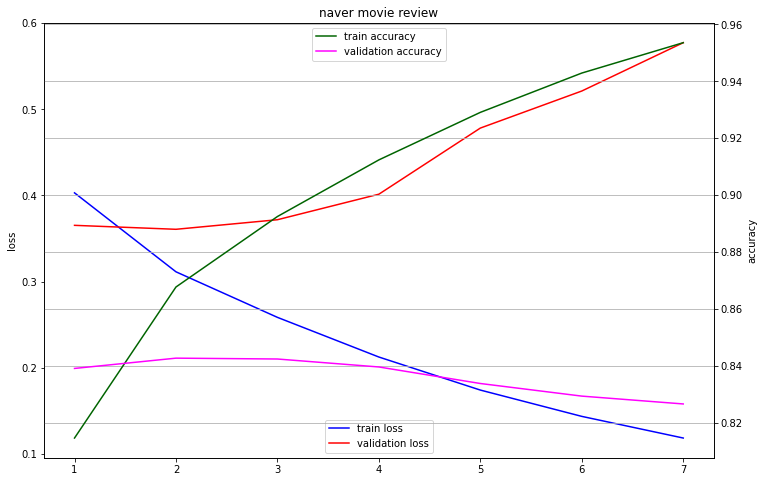

In [ ]:
# x축은 공유하고
# y축의 좌측: loss, y축의 우측: accuracy
import matplotlib.pyplot as plt
fig, ax0 = plt.subplots(figsize=(12,8))
ax1 = ax0.twinx()
ax0.plot(xs, y_loss, c='blue', label='train loss')
ax0.plot(xs, y_vloss, c='red', label='validation loss')
ax0.set_ylabel('loss')

ax1.plot(xs, y_acc, c='darkgreen', label='train accuracy')
ax1.plot(xs, y_vac, c='magenta', label='validation accuracy')
ax1.set_ylabel('accuracy')
ax0.legend(loc='lower center'); ax1.legend(loc='upper center')
plt.title("naver movie review"), plt.grid()
plt.show()

### Conv1D + GRU

In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dropout

In [ ]:
model2 = Sequential([
                     Embedding(num_words, 120, input_length=max_len),
                     Dropout(0.5),
                     Conv1D(64, 5, activation='relu'),
                     MaxPooling1D(5),
                     GRU(128),
                     Dense(1, activation='sigmoid')
                     ])
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 40, 120)           2400000   
                                                                 
 dropout (Dropout)           (None, 40, 120)           0         
                                                                 
 conv1d (Conv1D)             (None, 36, 64)            38464     
                                                                 
 max_pooling1d (MaxPooling1D  (None, 7, 64)            0         
 )                                                               
                                                                 
 gru (GRU)                   (None, 128)               74496     
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                      

In [ ]:
model2.compile('adam', 'binary_crossentropy', ['accuracy'])
model_path2 = 'best_naver_movie_conv1d_gru.h5'
mc2 = ModelCheckpoint(model_path2, verbose=1, save_best_only=True)
es2 = EarlyStopping(patience=2)

In [ ]:
hist2 = model2.fit(X_train, y_train, validation_split=0.2, epochs=30, batch_size=128, callbacks=[mc2,es2])

Epoch 1/30
727/727 [==============================] - ETA: 0s - loss: 0.4622 - accuracy: 0.7694
Epoch 1: val_loss improved from inf to 0.41144, saving model to best_naver_movie_conv1d_gru.h5
727/727 [==============================] - 17s 9ms/step - loss: 0.4622 - accuracy: 0.7694 - val_loss: 0.4114 - val_accuracy: 0.8060
Epoch 2/30
720/727 [============================>.] - ETA: 0s - loss: 0.3671 - accuracy: 0.8333
Epoch 2: val_loss did not improve from 0.41144
727/727 [==============================] - 5s 7ms/step - loss: 0.3671 - accuracy: 0.8332 - val_loss: 0.4124 - val_accuracy: 0.8084
Epoch 3/30
720/727 [============================>.] - ETA: 0s - loss: 0.3156 - accuracy: 0.8597
Epoch 3: val_loss did not improve from 0.41144
727/727 [==============================] - 5s 8ms/step - loss: 0.3159 - accuracy: 0.8596 - val_loss: 0.4232 - val_accuracy: 0.8053


In [ ]:
best_model2=load_model(model_path2)
best_model2.evaluate(X_test, y_test)

909/909 [==============================] - 3s 3ms/step - loss: 0.4106 - accuracy: 0.8069


[0.41058632731437683, 0.8069053292274475]